# Measurement System Analysis (MSA): Gage R&R Study

## Case Study: Sleep Mode Current Testing on PCBA department

**Project Overview:**
This notebook demonstrates how to perform a Measurement System Analysis (MSA) using a Gage R&R approach in Python. In this scenario, an electronics manufacturing line experienced a sudden spike in failures during Functional Circuit Testing (FCT) for **Sleep Mode Current (µA)** on printed circuit board assemblies (PCBA).

Instead of rushing to modify the hardware design or replace components, we conduct a **10-3-3 Gage R&R study** (10 parts, 3 operators, 3 trials) to investigate if the manual clamping mechanism of the test fixture introduces operator-to-operator variation (Reproducibility issue).

**Objectives:**
1. Generate / simulate the collected Gage R&R data.
2. Visualize the variation between operators using modern plotting libraries (`seaborn`, `matplotlib`).
3. Identify potential root causes based on the statistical distribution.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Simulation (10-3-3 Design)
We simulate 90 data points representing 10 PCBAs measured by 3 Operators (`Operator_A`, `Operator_B`, `Operator_C`), with each measurement repeated 3 times.

*Note: We purposefully inject an operator effect of +2.5 µA for `Operator_B` to simulate incorrect clamping pressure or bad ergonomics.*

In [14]:
np.random.seed(42)
parts = np.repeat(np.arange(1, 11), 9)
operators = np.tile(np.repeat(['Operator_A', 'Operator_B', 'Operator_C'], 3), 10)

# True board values + how each person uses the machine + random noise
true_values = np.repeat(np.random.normal(50, 2, 10), 9)
operator_effect = np.tile(np.repeat([0.1, 2.5, -0.2], 3), 10) # Tech_B doesn't press the clamp hard enough
noise = np.random.normal(0, 0.4, 90)

In [15]:
# Create the dataframe
df = pd.DataFrame({
    'Part': parts.astype(str),
    'Operator': operators,
    'Measurement': true_values + operator_effect + noise
})

print(df.head(10))

  Part    Operator  Measurement
0    1  Operator_A    50.908061
1    1  Operator_A    50.907136
2    1  Operator_A    51.190213
3    1  Operator_B    52.728116
4    1  Operator_B    52.803461
5    1  Operator_B    53.268513
6    1  Operator_C    50.388296
7    1  Operator_C    50.919127
8    1  Operator_C    50.430219
9    2  Operator_A    49.258550


### Step 2: Data Visualization
To quickly assess the measurement system, we plot a **Boxplot** combined with a **Stripplot**. This allows us to see both the overall distribution (summary metrics) and every individual measurement point (raw data).

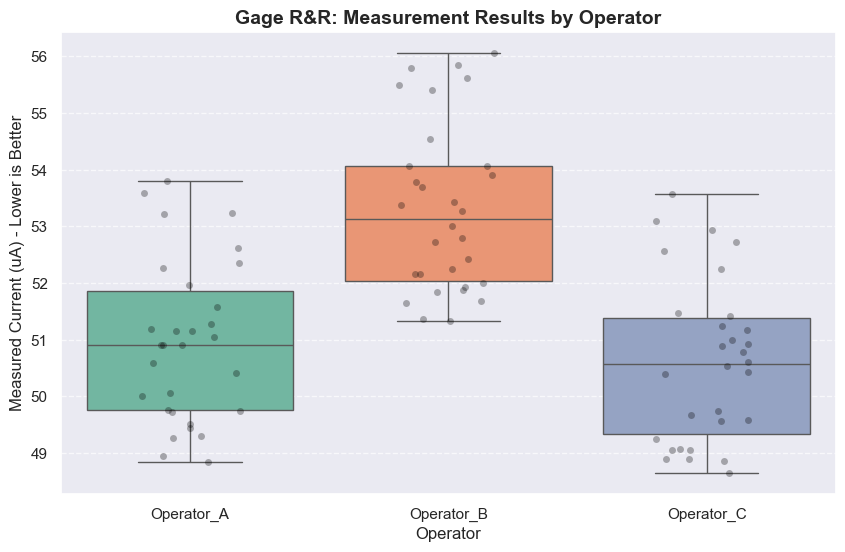

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Operator', y='Measurement', data=df, palette='Set2', hue='Operator')
sns.stripplot(x='Operator', y='Measurement', data=df, color='black', alpha=0.3, jitter=0.2)

plt.title('Gage R&R: Measurement Results by Operator', fontsize=14, fontweight='bold')
plt.xlabel('Operator', fontsize=12)
plt.ylabel('Measured Current (uA) - Lower is Better', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Step 3: Analysis & Conclusions

**Observations from the Chart:**
* **Operator_A** and **Operator_C** show tight, consistent distributions centered around the true board specification limit (~50 µA). Their equipment variation (**Repeatability**) is acceptable.
* **Operator_B** shows a significant upward shift in measurements, with a median close to 52.5 µA.

**Root Cause Analysis:**
Since all three operators measured the exact same set of 10 boards, the shift in `Operator_B`'s data is a clear textbook example of a **Reproducibility** issue (operator-to-operator variation). On a real PCBA departmnet, this typically points to: